# Table of Contents
- [EDA for the Datasets](#eda-for-the-datasets)
  - [data inspection](#data-inspection)
  - [Data prepration](#data-prepration)
    - [I have noticed that Merchant name is begin by M and Customer name is beign by C and new column that represent the hour of the day](#i-have-noticed-that-merchant-name-is-begin-by-m-and-customer-name-is-beign-by-c-and-new-column-that-represent-the-hour-of-the-day)
    - [let's cancle the ids column of the Orig and Dest (they didn't make any sense)](#lets-cancle-the-ids-column-of-the-orig-and-dest-they-didnt-make-any-sense)
  - [Data visilsation](#data-visilsation)
    - [univariate visilisation](#univariate-visilisation)
      - [the type column visilisation](#the-type-column-visilisation)
      - [the amount column outliers visilisation](#the-amount-column-outliers-visilisation)
      - [the OrigType, DestType column visilisation](#the-origtype-desttype-column-visilisation)
      - [the oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest column visilisation](#the-oldbalanceorg-newbalanceorig-oldbalancedest-newbalancedest-column-visilisation)
    - [Target variable analysis](#target-variable-analysis)
      - [isFraud column visilasation](#isfraud-column-visilasation)
    - [Bivariate Analysis](#bivariate-analysis)
      - [Amount VS type ploxblot](#amount-vs-type-ploxblot)
      - [Legitimate and Fruad Transaction](#legitimate-and-fruad-transaction)
      - [Fruad transaction distribution vs hours of day](#fruad-transaction-distribution-vs-hours-of-day)
        - [notices that the fruad transaction is continues in every hour](#notices-that-the-fruad-transaction-is-continues-in-every-hour)
      - [legitimate transactions distribution vs hours of day](#legitimate-transactions-distribution-vs-hours-of-day)
      - [Relationship between Amount and Old Balance in Fruad Cases](#relationship-between-amount-and-old-balance-in-fruad-cases)
        - [notice the linear dependance in the interval [0, 1] means the theaves want to steal all the money](#notice-the-linear-dependance-in-the-interval-0-1-means-the-theaves-want-to-steal-all-the-money)
  - [Data preprocessing](#data-preprocessing)
    - [Encoding](#encoding)
    - [Data Scaling](#data-scaling)
    - [Correlation Matrix](#correlation-matrix)


# EDA for the Datasets

## data inspection

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
## explore the dataset
df = pd.read_csv('PS_20174392719_1491204439457_log.csv')
df.head()
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Data prepration

### I have noticed that Merchant name is begin by M and Customer name is beign by C and new column that represent the hour of the day

In [3]:
# let's add new column that tell about the origins and destination type
df['OrigType'] = df['nameOrig'].str[0]
df['DestType'] = df['nameDest'].str[0]
df['hour_of_day'] = df['step'] % 24

### let's cancle the ids column of the Orig and Dest (they didn't make any sense)

In [4]:
column_to_drop = ['nameOrig', 'nameDest']
df = df.drop(columns=column_to_drop)

## Data visilsation

### univariate visilisation

#### the type column visilisation

C:\Users\DCS\AppData\Local\Temp\ipykernel_12236\1769898389.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='Set2')


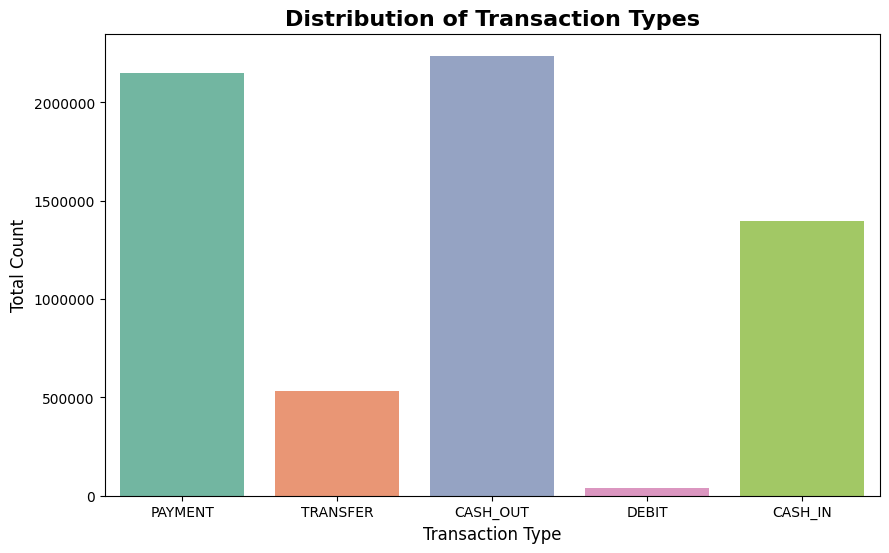

In [5]:
plt.figure(figsize=(10, 6))

sns.countplot(x='type', data=df, palette='Set2')

plt.title('Distribution of Transaction Types', fontsize=16, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

#### the amount column outliers visilisation

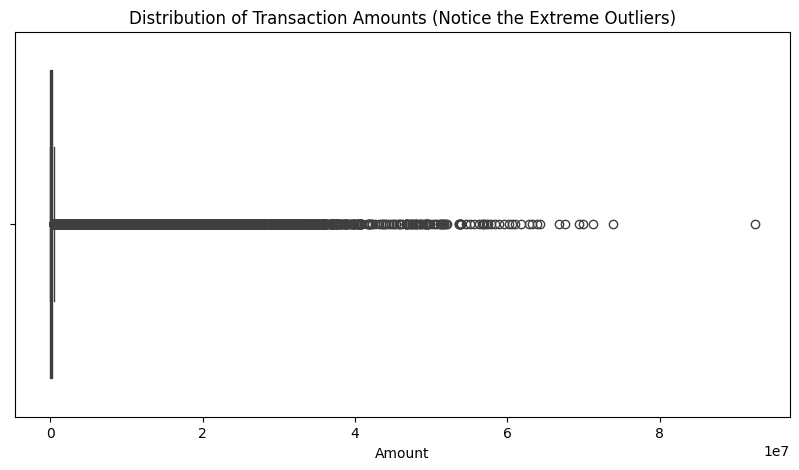

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['amount'])
plt.title('Distribution of Transaction Amounts (Notice the Extreme Outliers)')
plt.xlabel('Amount')
plt.show()

#### the OrigType, DestType column visilisation

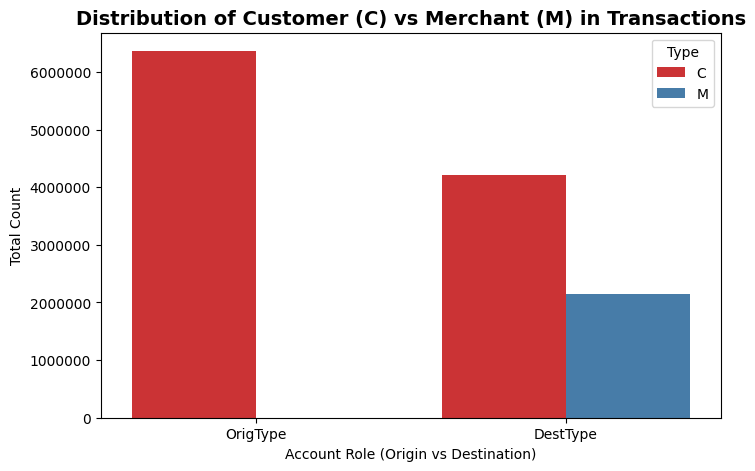

In [7]:
types_df = df[['OrigType', 'DestType']].melt(var_name='Role', value_name='Type')
plt.figure(figsize=(8, 5))
sns.countplot(x='Role', hue='Type', data=types_df, palette='Set1')
plt.title('Distribution of Customer (C) vs Merchant (M) in Transactions', fontsize=14, fontweight='bold')
plt.ylabel('Total Count')
plt.xlabel('Account Role (Origin vs Destination)')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

#### the oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest column visilisation

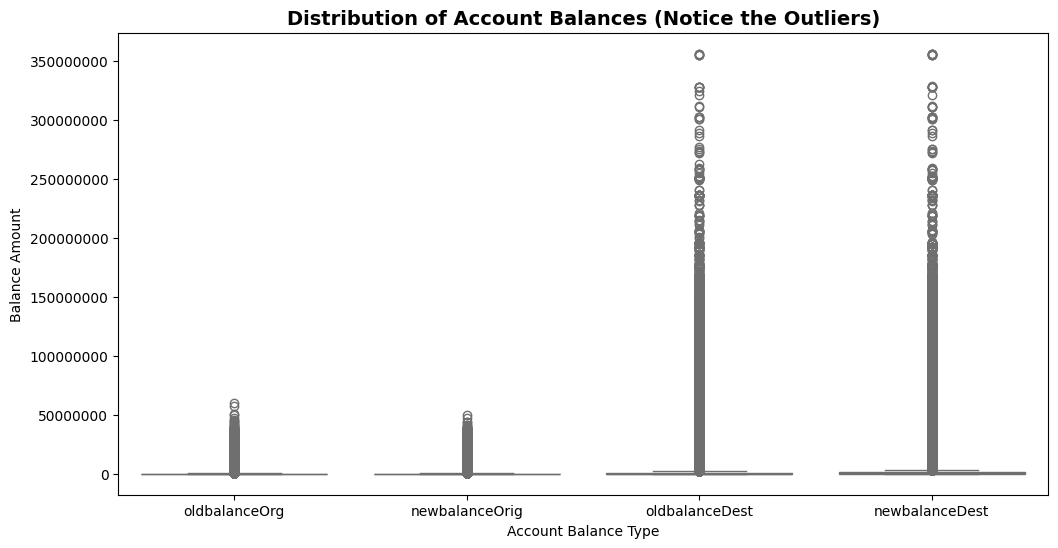

In [8]:
plt.figure(figsize=(12, 6))

balances = df[['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
sns.boxplot(data=balances, palette='pastel')
plt.title('Distribution of Account Balances (Notice the Outliers)', fontsize=14, fontweight='bold')
plt.ylabel('Balance Amount')
plt.xlabel('Account Balance Type')
plt.ticklabel_format(style='plain', axis='y')

plt.show()

### Target variable analysis

#### isFraud column visilasation

C:\Users\DCS\AppData\Local\Temp\ipykernel_12236\2695608369.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='isFraud', palette='Set2')


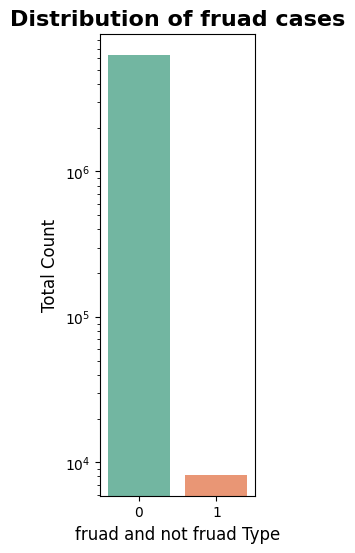

In [9]:
plt.figure(figsize=(2, 6))

sns.countplot(data=df, x='isFraud', palette='Set2')
plt.title('Distribution of fruad cases', fontsize=16, fontweight='bold')
plt.xlabel('fruad and not fruad Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.yscale('log')
plt.show()

### Bivariate Analysis

#### Amount VS type ploxblot

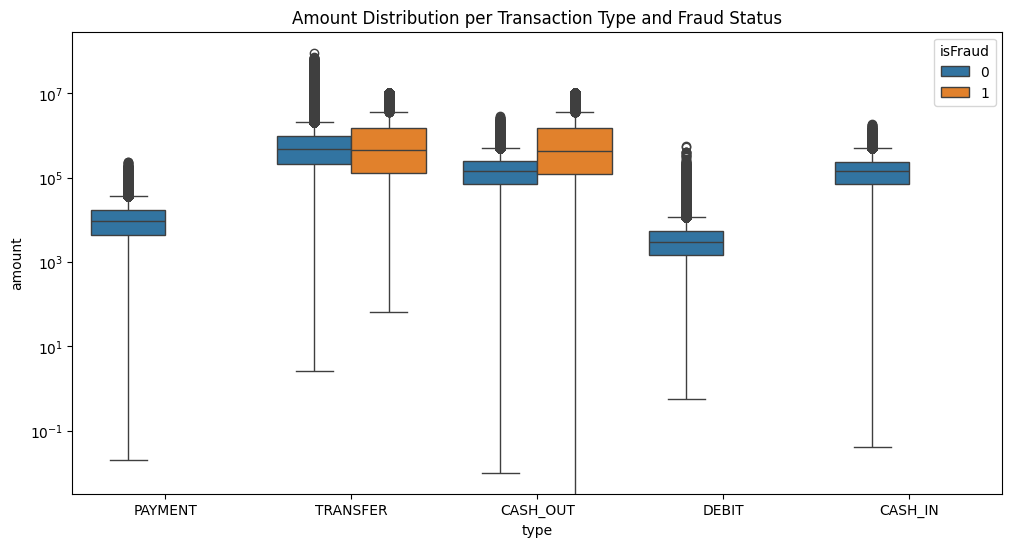

In [10]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='type', y='amount', hue='isFraud', data=df)
plt.yscale('log') 
plt.title('Amount Distribution per Transaction Type and Fraud Status')
plt.show()

#### Legitimate and Fruad Transaction

C:\Users\DCS\AppData\Local\Temp\ipykernel_12236\2920672845.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['isFraud'] == 0]['step'], label='Legitimate', shade=True)
C:\Users\DCS\AppData\Local\Temp\ipykernel_12236\2920672845.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['isFraud'] == 1]['step'], label='Fraud', shade=True)


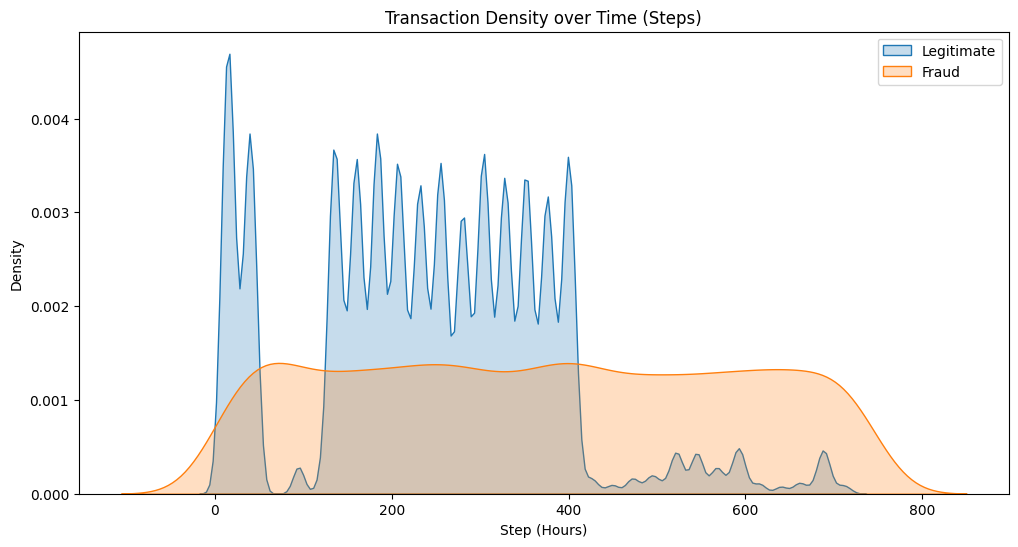

In [11]:
plt.figure(figsize=(12, 6))

sns.kdeplot(data=df[df['isFraud'] == 0]['step'], label='Legitimate', shade=True)
sns.kdeplot(data=df[df['isFraud'] == 1]['step'], label='Fraud', shade=True)
plt.title('Transaction Density over Time (Steps)')
plt.xlabel('Step (Hours)')
plt.legend()
plt.show()

#### Fruad transaction distribution vs hours of day

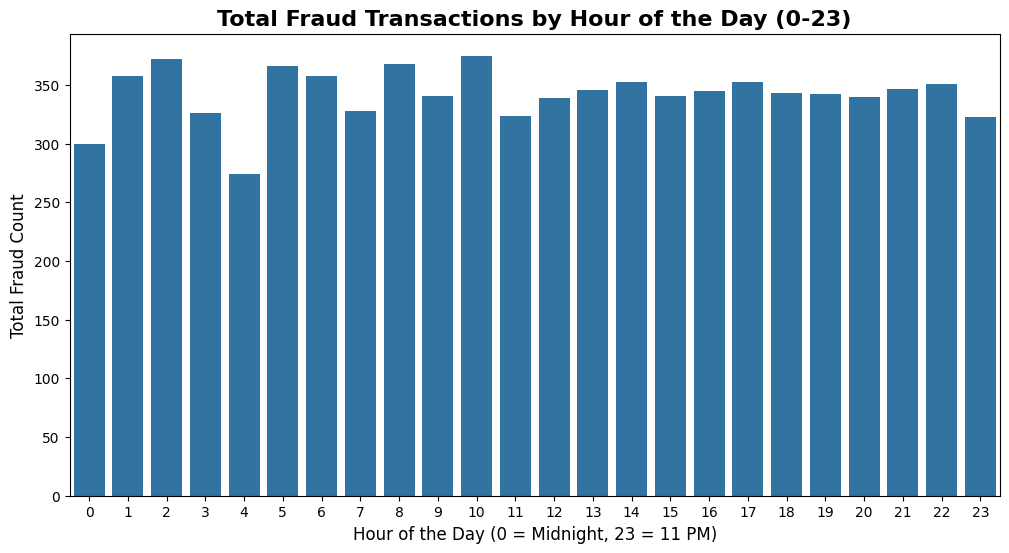

In [12]:


fraud_data = df[df['isFraud'] == 1]

fraud_counts_per_hour = fraud_data.groupby('hour_of_day').size().reset_index(name='fraud_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=fraud_counts_per_hour, x='hour_of_day', y='fraud_count')

plt.title('Total Fraud Transactions by Hour of the Day (0-23)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Total Fraud Count', fontsize=12)

plt.xticks(range(0, 24))

plt.show()

##### notices that the fruad transaction is continues in every hour

#### legitimate transactions distribution vs hours of day

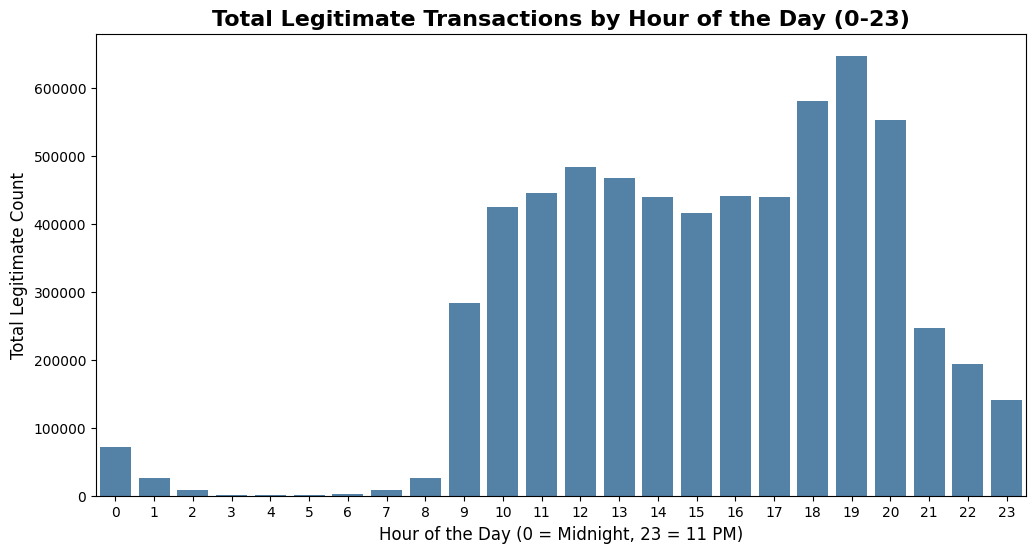

In [13]:
legit_data = df[df['isFraud'] == 0]

legit_counts_per_hour = legit_data.groupby('hour_of_day').size().reset_index(name='legit_count')

plt.figure(figsize=(12, 6))

sns.barplot(data=legit_counts_per_hour, x='hour_of_day', y='legit_count', color='steelblue')

plt.title('Total Legitimate Transactions by Hour of the Day (0-23)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0 = Midnight, 23 = 11 PM)', fontsize=12)
plt.ylabel('Total Legitimate Count', fontsize=12)

plt.ticklabel_format(style='plain', axis='y')
plt.xticks(range(0, 24))

plt.show()

#### Relationship between Amount and Old Balance in Fruad Cases

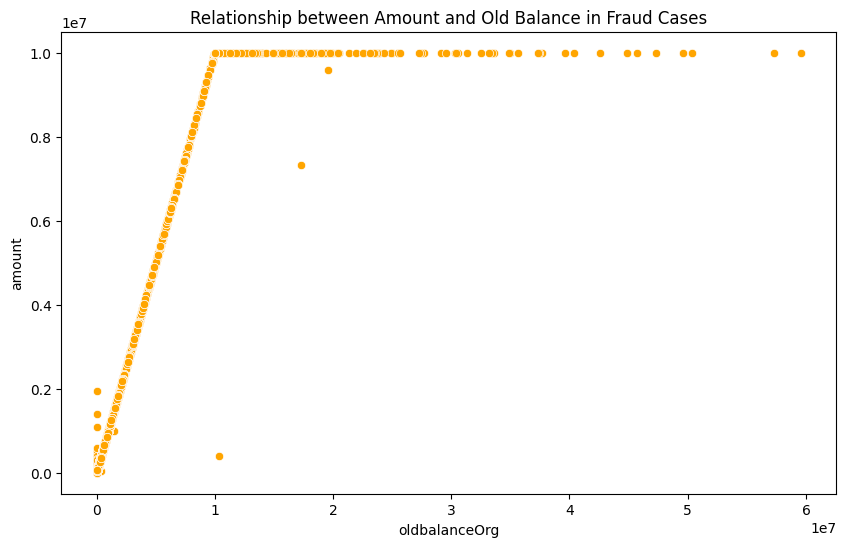

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='oldbalanceOrg', y='amount', data=df[df['isFraud'] == 1], color='orange')
plt.title('Relationship between Amount and Old Balance in Fraud Cases')
plt.show()

##### notice the linear dependance in the interval [0, 1] means the theaves want to steal all the money 

In [15]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,OrigType,DestType,hour_of_day
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0,C,M,1
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0,C,M,1
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0,C,C,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0,C,C,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0,C,M,1


## Data preprocessing

### Encoding

In [16]:

df = df.drop(columns=['OrigType'])

df['DestType'] = df['DestType'].map({'C': 0, 'M': 1})

df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,DestType,hour_of_day,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,1,1,0,0,1,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,1,1,0,0,1,0
2,1,181.00,181.0,0.00,0.0,0.0,1,0,0,1,0,0,0,1
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,0,1,1,0,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,1,1,0,0,1,0


### Data Scaling

In [17]:
cols_to_scale = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step']

scaler = RobustScaler() # x_scaled = (x - Q2) / (Q3 - Q1)

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

df[cols_to_scale].head()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,step
0,-0.332932,1.452991,1.111175,-0.140722,-0.193057,-1.329609
1,-0.373762,0.065610,0.134375,-0.140722,-0.193057,-1.329609
2,-0.382380,-0.130708,0.000000,-0.140722,-0.193057,-1.329609
3,-0.382380,-0.130708,0.000000,-0.118260,-0.193057,-1.329609
4,-0.323571,0.254820,0.207169,-0.140722,-0.193057,-1.329609


### Correlation Matrix

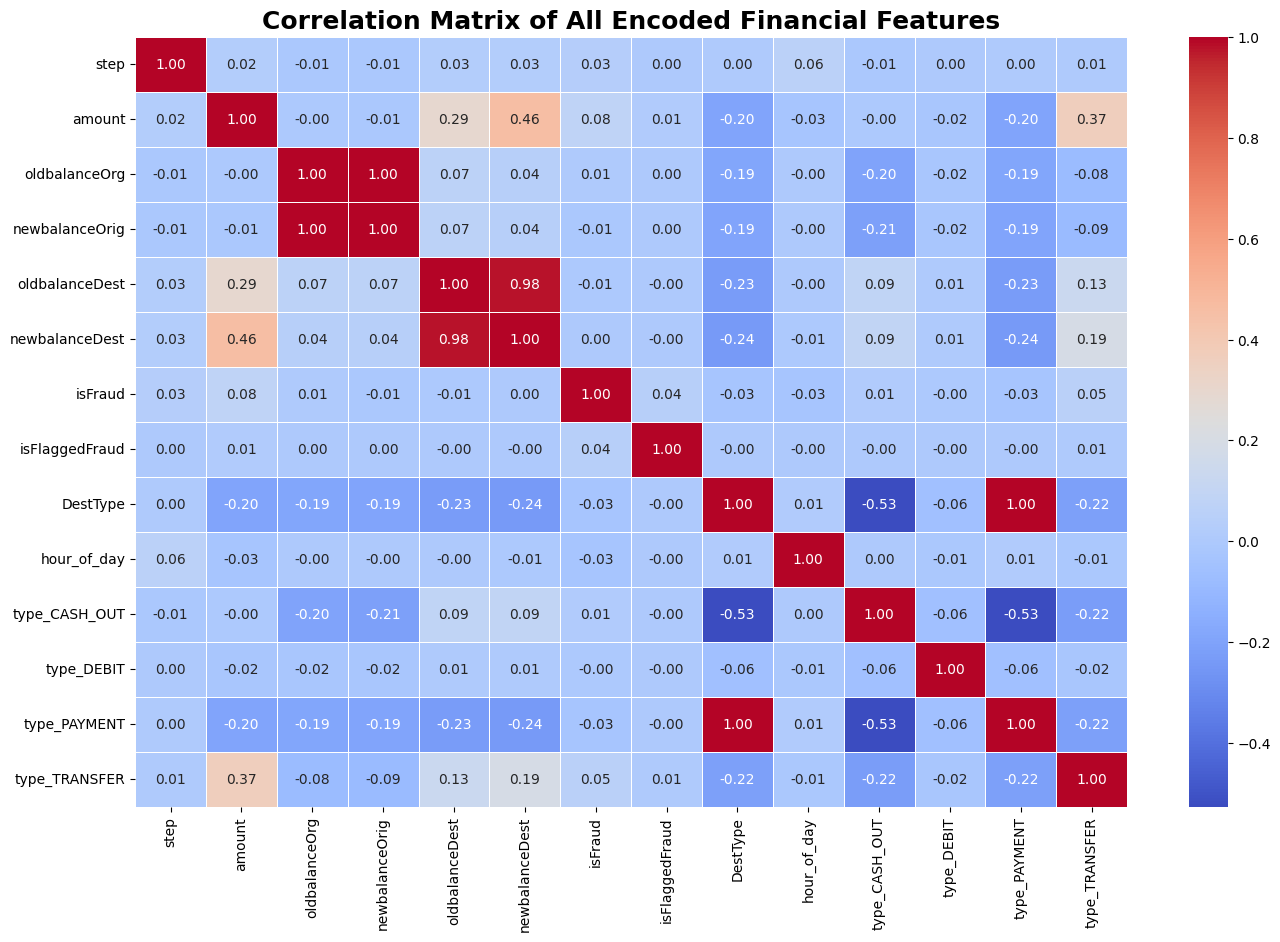

In [18]:

plt.figure(figsize=(16, 10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Matrix of All Encoded Financial Features', fontsize=18, fontweight='bold')

plt.show()

The correlation matrix reveals significant multicollinearity among financial features, specifically between account balance pairs (Origin and Destination), with coefficients approaching 1.0. This redundancy provides a strong mathematical justification for applying Principal Component Analysis (PCA) to reduce dimensionality and eliminate noise. Additionally, the weak linear correlation between individual features and the target variable (isFraud) suggests that fraudulent patterns are non-linear and complex, necessitating the use of advanced ensemble models like XGBoost for effective detection.

🗑️ Columns dropped due to 100% correlation: ['newbalanceOrig', 'type_PAYMENT']


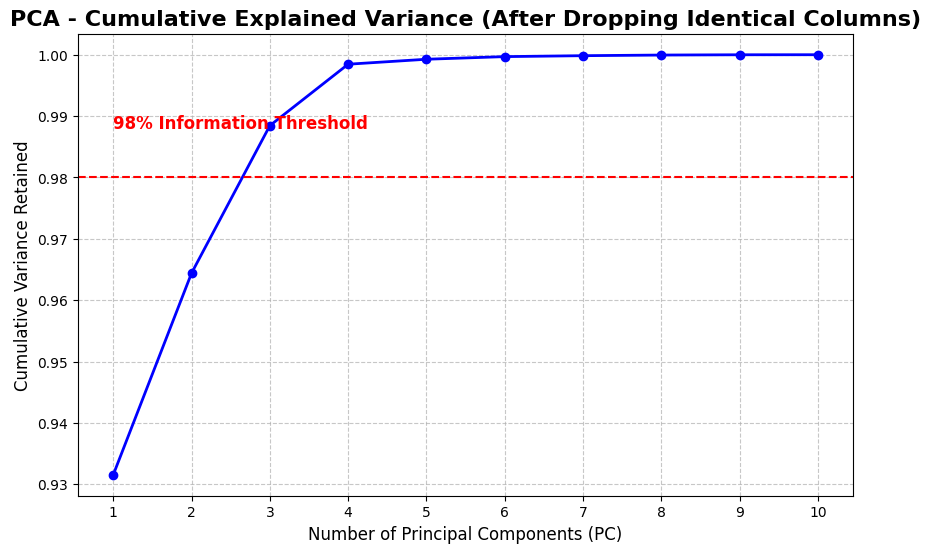

In [ ]:


# ==========================================
# الخطوة الأولى: التخلص من العواميد المتطابقة 100%
# ==========================================

X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

corr_matrix = X.corr().abs()

corr_matrix = X.corr().abs()

columns_to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        
        if corr_matrix.iloc[i, j] > 0.99:
            colname = corr_matrix.columns[j]
            columns_to_drop.add(colname)

columns_to_drop = list(columns_to_drop)

X_filtered = X.drop(columns=columns_to_drop)

# ==========================================
# الخطوة التانية: تطبيق الـ PCA على الداتا النضيفة
# ==========================================

pca_test = PCA()
pca_test.fit(X_filtered)

cumulative_variance = np.cumsum(pca_test.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='b', linewidth=2)

plt.axhline(y=0.98, color='r', linestyle='--')
plt.text(1, 0.988, '98% Information Threshold', color='red', fontsize=12, fontweight='bold')

plt.title('PCA - Cumulative Explained Variance (After Dropping Identical Columns)', fontsize=16, fontweight='bold')
plt.xlabel('Number of Principal Components (PC)', fontsize=12)
plt.ylabel('Cumulative Variance Retained', fontsize=12)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.decomposition import PCA

pca_final = PCA(n_components=3)

X_pca = pca_final.fit_transform(X_filtered)

df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2', 'PC3'])

df_pca['isFraud'] = y.values

print("New Data Shape:", df_pca.shape)
print(df_pca.head())

New Data Shape: (6362620, 4)
        PC1       PC2        PC3  isFraud
0 -6.199043 -1.331697 -14.366551        0
1 -7.586319 -1.331812 -14.365397        0
2 -7.780121 -1.297323 -14.366005        1
3 -7.782640 -1.285509 -14.364170        1
4 -7.397135 -1.316982 -14.366443        0


c:\Users\DCS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:21:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.54      0.12      0.20      1643

    accuracy                           1.00   1272524
   macro avg       0.77      0.56      0.60   1272524
weighted avg       1.00      1.00      1.00   1272524



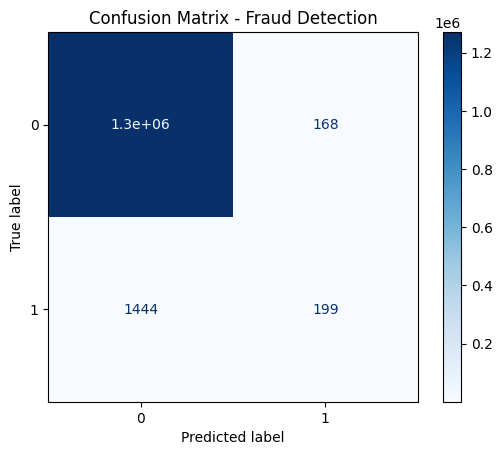

In [ ]:
X_final = df_pca.drop(columns=['isFraud'])
y_final = df_pca['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

model_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Fraud Detection')
plt.show()

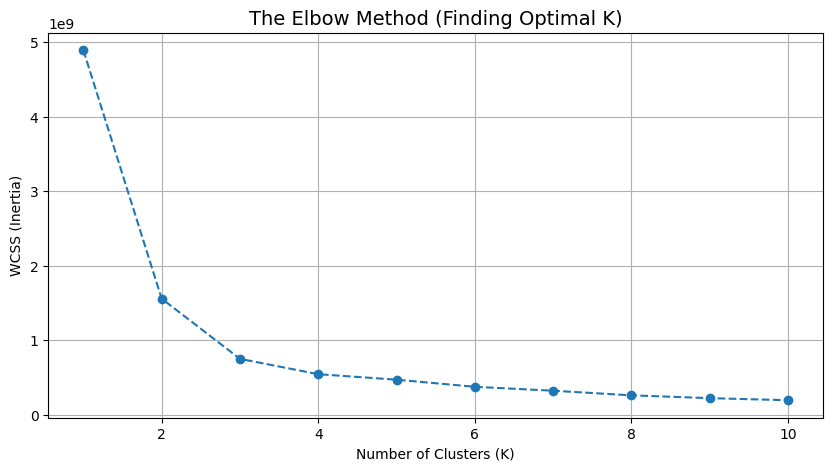

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X_pca_data = df_pca[['PC1', 'PC2', 'PC3']]

wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_pca_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (Finding Optimal K)', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 4 

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(X_pca_data)

X_with_clusters = X_filtered.copy()
X_with_clusters['behavioral_segment'] = cluster_labels

print("✅ Successfully added 'behavioral_segment' to the original features!")
print(X_with_clusters.head())

✅ Successfully added 'behavioral_segment' to the original features!
       step    amount  oldbalanceOrg  oldbalanceDest  newbalanceDest  \
0 -1.329609 -0.332932       1.452991       -0.140722       -0.193057   
1 -1.329609 -0.373762       0.065610       -0.140722       -0.193057   
2 -1.329609 -0.382380      -0.130708       -0.140722       -0.193057   
3 -1.329609 -0.382380      -0.130708       -0.118260       -0.193057   
4 -1.329609 -0.323571       0.254820       -0.140722       -0.193057   

   DestType  hour_of_day  type_CASH_OUT  type_DEBIT  type_TRANSFER  \
0         1            1              0           0              0   
1         1            1              0           0              0   
2         0            1              0           0              1   
3         0            1              1           0              0   
4         1            1              0           0              0   

   behavioral_segment  
0                   0  
1                   0  
2     

⚖️ Scale Pos Weight calculated: 773.75
Training XGBoost... this might take a minute...

📊 Phase 4 Classification Report (Hybrid Model):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.16      0.98      0.27      1643

    accuracy                           0.99   1272524
   macro avg       0.58      0.99      0.64   1272524
weighted avg       1.00      0.99      1.00   1272524



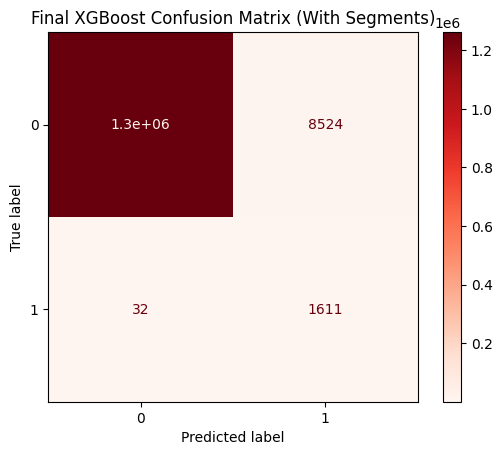

In [ ]:
X_phase4 = X_with_clusters 
y_phase4 = y

X_train, X_test, y_train, y_test = train_test_split(X_phase4, y_phase4, test_size=0.2, random_state=42, stratify=y_phase4)

weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_final = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_final.fit(X_train, y_train)
y_pred_final = xgb_final.predict(X_test)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_final))
disp.plot(cmap='Reds')
plt.title('Final XGBoost Confusion Matrix (With Segments)')
plt.show()